
Training MLP with MAE loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0810 - val_loss: 0.0604
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step - loss: 0.0557 - val_loss: 0.0622
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0495 - val_loss: 0.0602
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - loss: 0.0573 - val_loss: 0.0581
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - loss: 0.0485 - val_loss: 0.0522
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0447 - val_loss: 0.0504
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - loss: 0.0506 - val_loss: 0.0507
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0444 - val_loss: 0.0512
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - loss: 0.0418 - val_loss: 0.0506
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 938us/step - loss: 0.0412 - val_loss: 0.0491
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step - loss: 0.0422 - val_loss: 0.0501
Epoch 12/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - loss: 0.0421 - v

Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


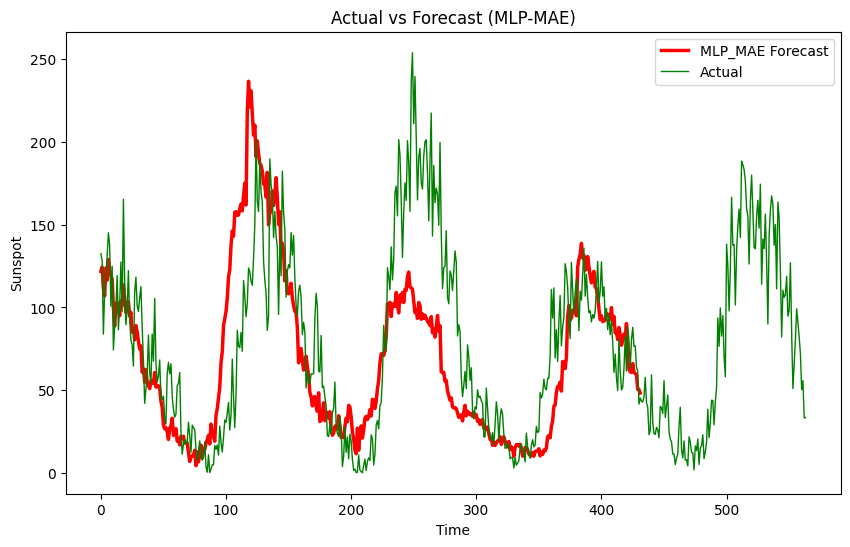


Evaluation Metrics
MSE   : 724.6353038076879
RMSE  : 26.91905094552347
NRMSE: 0.10614767722998213
MAE   : 20.09695165437793
SMAPE : 35.96743925900378
MASE  : 1.357114949163633


In [1]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. TRAIN MODEL (MAE LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with MAE loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=tf.keras.losses.MeanAbsoluteError()
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 4. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(cfg['model_path'])

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 5. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 6. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_MAE Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-MAE)")
    plt.legend()
    plt.show()


# =========================================================
# 7. METRICS
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 8. CONFIGURATION (ALL PATHS FILLED)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_train_sunspot_full.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_train_sunspot_full.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV (FOR INVERSE SCALING + PLOT)
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mae_sunspot_final.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mae_daily_sunspot_loss_history.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_rescaled.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mae_sunspot_rescaled.csv"
}


# =========================================================
# 9. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with MSE loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0191 - val_loss: 0.0079
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - loss: 0.0064 - val_loss: 0.0067
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - loss: 0.0046 - val_loss: 0.0056
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step - loss: 0.0043 - val_loss: 0.0054
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step - loss: 0.0044 - val_loss: 0.0053
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - loss: 0.0044 - val_loss: 0.0052
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - loss: 0.0039 - val_loss: 0.0069
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - loss: 0.0047 - val_loss: 0.0050
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0034 - val_loss: 0.0052
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - loss: 0.0039 - val_loss: 0.0058
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0036 - val_loss: 0.0048
Epoch 12/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step - loss: 0.0033 -

Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


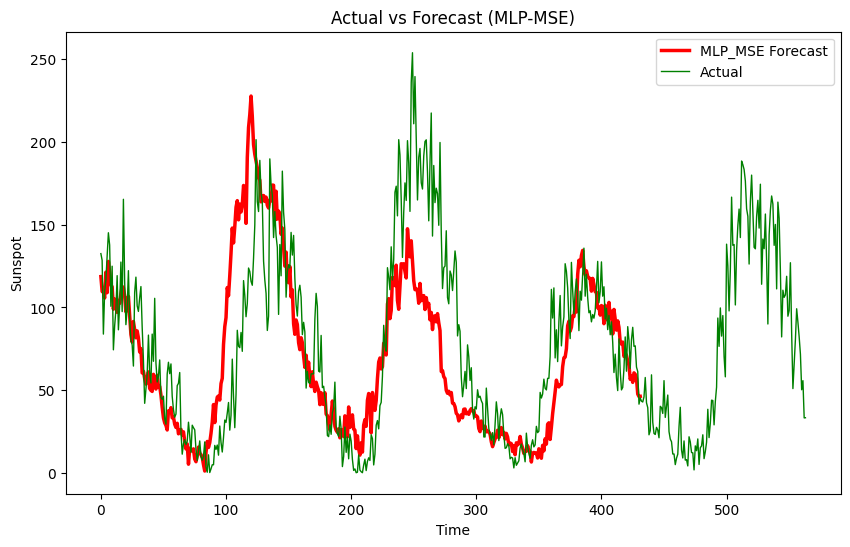


Evaluation Metrics
MSE   : 771.0222344950648
RMSE  : 27.767287128833182
NRMSE: 0.10949245713262294
MAE   : 20.81735968619566
SMAPE : 36.99485029222744
MASE  : 1.4057629494320922


In [2]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. TRAIN MODEL (MSE LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with MSE loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=tf.keras.losses.MeanSquaredError()
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 4. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(cfg['model_path'])

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 5. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 6. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_MSE Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-MSE)")
    plt.legend()
    plt.show()


# =========================================================
# 7. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 8. CONFIGURATION (MSE NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_train_sunspot_full.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_train_sunspot_full.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mse_sunspot_final.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_mse_sunspot_loss_history.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_rescaled.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_mse_sunspot_rescaled.csv"
}


# =========================================================
# 9. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Huber loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0041 - val_loss: 0.0027
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - loss: 0.0020 - val_loss: 0.0024
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0018 - val_loss: 0.0023
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - loss: 0.0019 - val_loss: 0.0021
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0016 - val_loss: 0.0022
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0016 - val_loss: 0.0023
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0018 - val_loss: 0.0027
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 869us/step - loss: 0.0019 - val_loss: 0.0020
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - loss: 0.0013 - val_loss: 0.0021
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


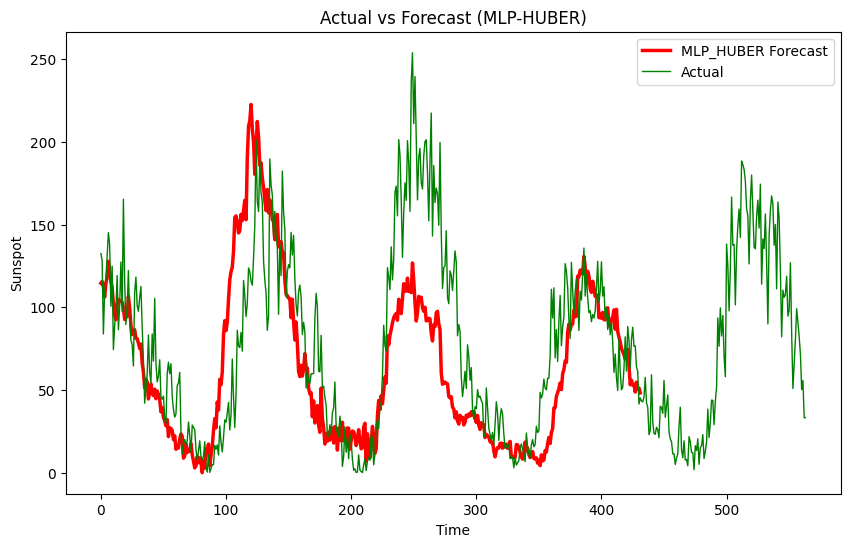


Evaluation Metrics
MSE   : 814.7913545220077
RMSE  : 28.54455034716798
NRMSE: 0.11255737518599361
MAE   : 21.244088253952864
SMAPE : 38.73072887338259
MASE  : 1.4345792459778588


In [3]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. HUBER LOSS (CUSTOM DEFINITION)
# =========================================================
def huber_loss(delta=1.0):
    def loss(y_true, y_pred):
        error = y_true - y_pred
        abs_error = tf.abs(error)
        quadratic = tf.minimum(abs_error, delta)
        linear = abs_error - quadratic
        return tf.reduce_mean(0.5 * tf.square(quadratic) + delta * linear)
    return loss


# =========================================================
# 4. TRAIN MODEL (HUBER LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with Huber loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=huber_loss(delta=cfg['huber_delta'])
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)
    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={'loss': huber_loss(cfg['huber_delta'])}
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_HUBER Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-HUBER)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (HUBER NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    'huber_delta': 0.103,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_train_sunspot_full.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_train_sunspot_full.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_huber_sunspot_final.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_huber_sunspot_loss_history.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_rescaled.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_huber_sunspot_rescaled.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Log-Cosh loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0128 - val_loss: 0.0032
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0026 - val_loss: 0.0030
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - loss: 0.0025 - val_loss: 0.0028
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - loss: 0.0023 - val_loss: 0.0025
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - loss: 0.0021 - val_loss: 0.0027
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step - loss: 0.0018 - val_loss: 0.0025
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - loss: 0.0018 - val_loss: 0.0026
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0021 - val_loss: 0.0023
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0017 - val_loss: 0.0023
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0017 - val_loss: 0.0024
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - loss: 0.0018 - val_loss: 0.0023
Epoch 12/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0016 - val_l

Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


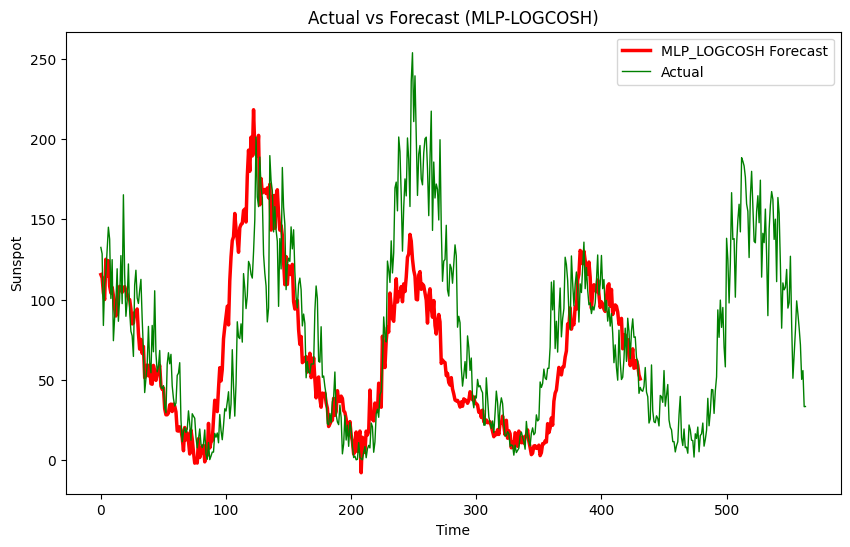


Evaluation Metrics
MSE   : 826.4613095470739
RMSE  : 28.74824011217163
NRMSE: 0.11336056826566099
MAE   : 21.549862382453394
SMAPE : 39.69021154681753
MASE  : 1.4552276830140873


In [4]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 3. LOG-COSH LOSS (CUSTOM DEFINITION)
# =========================================================
def logcosh_loss(y_true, y_pred):
    return tf.reduce_mean(tf.math.log(tf.cosh(y_pred - y_true)))


# =========================================================
# 4. TRAIN MODEL (LOG-COSH LOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP with Log-Cosh loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=logcosh_loss
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={'logcosh_loss': logcosh_loss}
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)
    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_LOGCOSH Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-LOGCOSH)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (LOG-COSH NAMING)
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_train_sunspot_full.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_train_sunspot_full.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_logcosh_sunspot_final.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_logcosh_sunspot_loss_history.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_rescaled.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_logcosh_sunspot_rescaled.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP using RoBoSS loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.5480e-04 - val_loss: 7.8919e-05
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - loss: 4.8358e-05 - val_loss: 6.9806e-05
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - loss: 3.4749e-05 - val_loss: 5.4722e-05
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step - loss: 2.7505e-05 - val_loss: 5.7240e-05
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - loss: 2.2850e-05 - val_loss: 5.9638e-05
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - loss: 2.4970e-05 - val_loss: 5.0172e-05
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


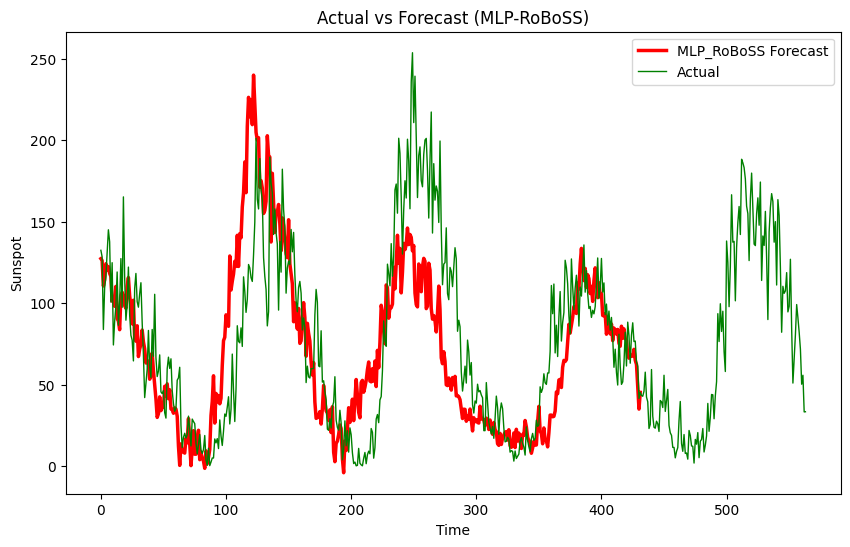


Evaluation Metrics
MSE   : 988.8330560015747
RMSE  : 31.445716019858327
NRMSE: 0.12399730291742242
MAE   : 24.616629841515614
SMAPE : 43.572057708388996
MASE  : 1.662321576450173


In [5]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import gc
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. ROBOSS LOSS
# =========================================================
def roboss_nn_loss(y_true, y_pred, a, epsilon, lam):
    u = tf.abs(y_true - y_pred)
    val = a * tf.sqrt(tf.square(u) + epsilon) - a * tf.sqrt(epsilon)
    loss_val = lam * (1 - (val + 1) * tf.exp(-val))
    return tf.reduce_mean(loss_val)


# =========================================================
# 2. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):
    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=validation_split, random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
        .shuffle(len(x_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_data = tf.data.Dataset.from_tensor_slices((x_val, y_val)) \
        .batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_data, val_data


# =========================================================
# 3. BUILD MLP
# =========================================================
def build_mlp():
    seq_size = 132
    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model


# =========================================================
# 4. TRAIN MODEL (ROBOSS)
# =========================================================
def train_model(cfg):
    print("\nTraining MLP using RoBoSS loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    def dynamic_roboss_loss(y_true, y_pred):
        return roboss_nn_loss(y_true, y_pred, cfg['a'], cfg['epsilon'], cfg['lam'])

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg['learning_rate'], amsgrad=True),
        loss=dynamic_roboss_loss
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(cfg['model_path'])
    pd.DataFrame(history.history).to_csv(cfg['loss_path'], index=False)

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):
    print("Generating forecasts")

    x_test = np.load(cfg['x_test_path']).reshape(-1, 132, 1)

    def dynamic_roboss_loss(y_true, y_pred):
        return roboss_nn_loss(y_true, y_pred, cfg['a'], cfg['epsilon'], cfg['lam'])

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'dynamic_roboss_loss': dynamic_roboss_loss,
            'roboss_nn_loss': roboss_nn_loss
        }
    )

    y_hat = model.predict(x_test)

    np.save(cfg['forecast_npy'], y_hat)
    np.savetxt(cfg['forecast_csv'], y_hat, delimiter=',')


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):
    df_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_hat = pd.read_csv(cfg['forecast_csv'], header=None).values.flatten()

    scaler = MinMaxScaler()
    inverse_preds = []

    for i in range(len(df_actual) - 132):
        window = np.array(df_actual.iloc[i:i+132]).reshape(-1, 1)
        scaler.fit(window)
        inverse_preds.append(
            scaler.inverse_transform([[y_hat[i]]])[0][0]
        )

    inverse_preds = np.array(inverse_preds)

    np.save(cfg['forecast_rescaled_npy'], inverse_preds)
    np.savetxt(cfg['forecast_rescaled_csv'], inverse_preds, delimiter=',')


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):
    y_actual = pd.read_csv(cfg['actual_test_csv'], usecols=[1])
    y_pred = pd.read_csv(cfg['forecast_rescaled_csv'], header=None)

    plt.figure(figsize=(10, 6))
    plt.plot(y_pred, label="MLP_RoBoSS Forecast", color='red', linewidth=2.5)
    plt.plot(y_actual, label="Actual", color='green', linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("Sunspot")
    plt.title("Actual vs Forecast (MLP-RoBoSS)")
    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS
# =========================================================
def smape(y, yhat):
    return np.mean(200 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat)))

def mase(y, yhat):
    return np.mean(np.abs(y - yhat)) / np.mean(np.abs(y[1:] - y[:-1]))

def compute_metrics(cfg):
    y_test = np.load(cfg['y_test_npy'])
    y_pred = np.load(cfg['forecast_rescaled_npy'])

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_test) - np.min(y_test))
    mae = mean_absolute_error(y_test, y_pred)

    print("\nEvaluation Metrics")
    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE:", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION
# =========================================================
cfg = {
    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    'a': 1.045,
    'epsilon': 0.047,
    'lam': 0.149,

    # TRAIN / TEST DATA
    'x_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_train_sunspot_full.npy",
    'y_train_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_train_sunspot_full.npy",
    'x_test_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",
    'y_test_npy':   r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV (FOR INVERSE SCALING + PLOT)
    'actual_test_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_robos_sunspot_final.h5",
    'loss_path':  r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_robos_daily_sunspot_loss_history.csv",

    # FORECASTS
    'forecast_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot.npy",
    'forecast_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_rescaled.npy",
    'forecast_rescaled_csv': r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_robos_sunspot_rescaled.csv"
}




# =========================================================
# 10. RUN COMPLETE PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)



Training MLP with Cauchy loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0029 - val_loss: 0.0023
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0015 - val_loss: 0.0017
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - loss: 0.0013 - val_loss: 0.0016
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - loss: 0.0014 - val_loss: 0.0017
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - loss: 0.0013 - val_loss: 0.0015
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 0.0018
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 11: early stopping
Restoring model weights from the end of the best epoch

Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


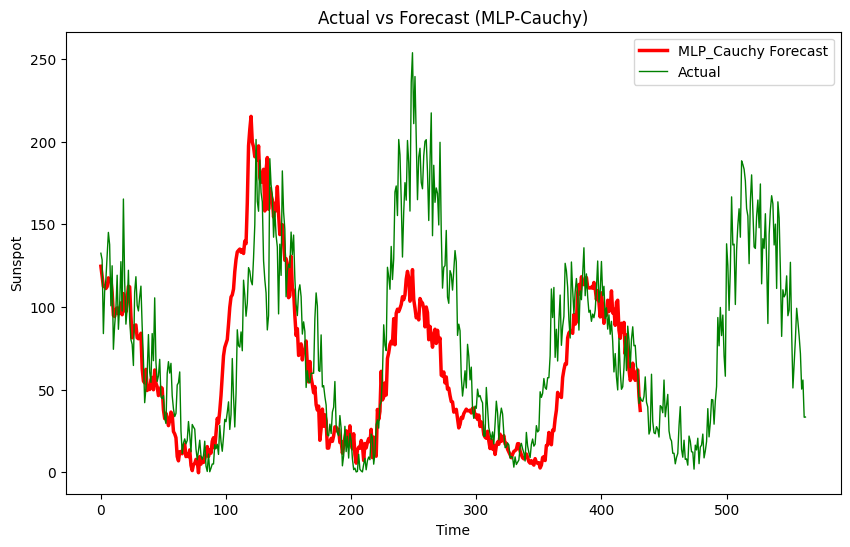


Evaluation Metrics
MSE   : 915.3908456427881
RMSE  : 30.255426713943205
NRMSE : 0.11930373309914512
MAE   : 22.202012073223667
SMAPE : 39.46586471825836
MASE  : 1.4992663068639875


In [7]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. CAUCHY LOSS
# =========================================================
def cauchy_loss(c=1.0):

    def loss(y_true, y_pred):

        error = y_true - y_pred

        loss_value = (
            (c ** 2) / 2.0
        ) * tf.math.log(
            1.0 + tf.square(error) / (c ** 2)
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (CAUCHY LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with Cauchy loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=cauchy_loss(
            c=cfg['cauchy_c']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': cauchy_loss(
                cfg['cauchy_c']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_Cauchy Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-Cauchy)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (CAUCHY NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # Cauchy parameter
    'cauchy_c': 0.101,

    # TRAIN / TEST DATA
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_train_sunspot_full.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_train_sunspot_full.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_cauchy_sunspot_final.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_cauchy_sunspot_loss_history.csv",

    # FORECASTS
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_rescaled.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_cauchy_sunspot_rescaled.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)


Training MLP with Tukey's Biweight loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0010 - val_loss: 8.6254e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.3191e-04 - val_loss: 8.9828e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.2759e-04 - val_loss: 8.1681e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.0766e-04 - val_loss: 7.9961e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.0237e-04 - val_loss: 8.2197e-04
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.3124e-04 - val_loss: 7.6203e-04
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.7492e-04 - val_loss: 8.1242e-04
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.7882e-04 - val_loss: 7.3128e-04
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.4387e-04 - val_loss: 7.5390e-04
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6414e-04 - val_loss: 7.3044e-04
Epoch 12/

Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


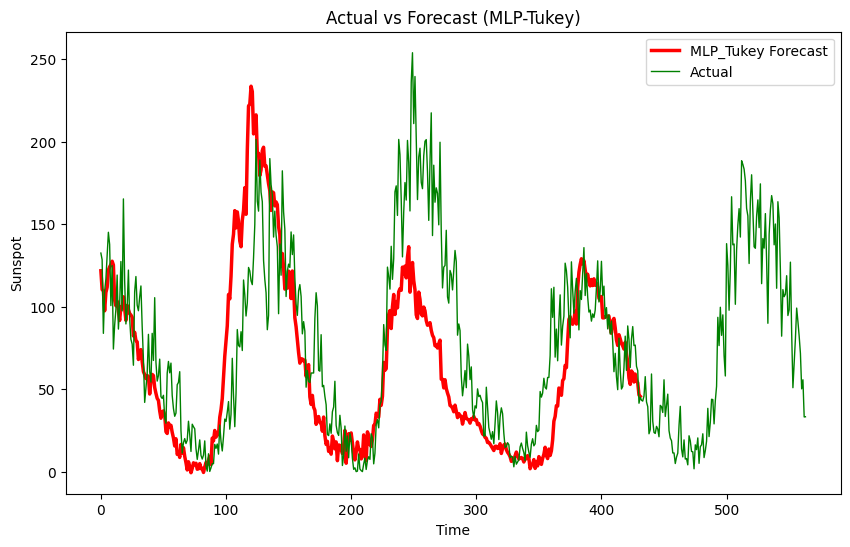


Evaluation Metrics
MSE   : 889.3868990311735
RMSE  : 29.82259041450245
NRMSE : 0.11759696535687085
MAE   : 22.30446820614332
SMAPE : 42.73107896053149
MASE  : 1.5061850053815542


In [8]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. TUKEY'S BIWEIGHT LOSS
# =========================================================
def tukey_biweight_loss(c=1.0):

    def loss(y_true, y_pred):

        error = y_true - y_pred

        abs_error = tf.abs(error)

        # Region where |r| <= c
        inside = abs_error <= c

        # Tukey biweight expression
        scaled_error = error / c

        inside_loss = (
            (c ** 2) / 6.0
        ) * (
            1.0 -
            tf.pow(
                1.0 - tf.square(scaled_error),
                3
            )
        )

        # Constant loss for |r| > c
        outside_loss = (
            (c ** 2) / 6.0
        ) * tf.ones_like(error)

        loss_value = tf.where(
            inside,
            inside_loss,
            outside_loss
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (TUKEY'S BIWEIGHT LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with Tukey's Biweight loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=tukey_biweight_loss(
            c=cfg['tukey_c']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': tukey_biweight_loss(
                cfg['tukey_c']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_Tukey Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-Tukey)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (TUKEY NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # Tukey's Biweight parameter
    'tukey_c': 0.101,

    # TRAIN / TEST DATA
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_train_sunspot_full.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_train_sunspot_full.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # RAW TEST CSV
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # MODEL & LOGS
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_tukey_sunspot_final.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_tukey_sunspot_loss_history.csv",

    # FORECASTS
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot.csv",

    # RESCALED FORECASTS
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_rescaled.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_tukey_sunspot_rescaled.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)


Training MLP with HawkEye loss
Epoch 1/50


c:\Users\hp5cd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0021 - val_loss: 2.7722e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.7508e-04 - val_loss: 2.0945e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.3289e-04 - val_loss: 1.8638e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4416e-04 - val_loss: 1.7094e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1137e-04 - val_loss: 1.7577e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - loss: 1.1777e-04 - val_loss: 1.7869e-04
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - loss: 1.0453e-04 - val_loss: 1.7464e-04
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0839e-04 - val_loss: 1.7741e-04
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0963e-04 - val_loss: 1.5822e-04
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.


Generating forecasts
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


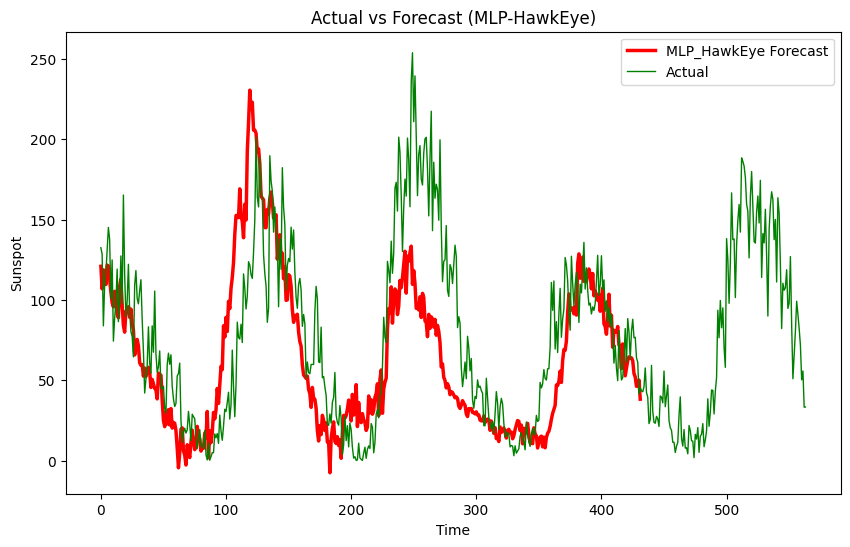


Evaluation Metrics
MSE   : 945.3315704943129
RMSE  : 30.746244819397262
NRMSE : 0.12123913572317531
MAE   : 23.075883197507615
SMAPE : 42.518430944560016
MASE  : 1.558277423913166


In [9]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
import os
import gc
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================================================
# 1. DATA GENERATOR
# =========================================================
def sample_generator_numeric(x_path, y_path, validation_split, batch_size):

    x = np.load(x_path)
    y = np.load(y_path)

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=validation_split,
        random_state=42
    )

    train_data = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train)
    ).shuffle(
        len(x_train)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    val_data = tf.data.Dataset.from_tensor_slices(
        (x_val, y_val)
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return train_data, val_data


# =========================================================
# 2. BUILD MLP
# =========================================================
def build_mlp():

    seq_size = 132

    model = Sequential([
        Flatten(input_shape=(seq_size, 1)),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
    ])

    return model


# =========================================================
# 3. HAWKEYE LOSS
# =========================================================
def hawkeye_loss(a=1.0, epsilon=0.02, lam=1.0):

    def loss(y_true, y_pred):

        # Residual
        r = y_true - y_pred

        # -------------------------------------------------
        # Left region: r <= -epsilon
        # -------------------------------------------------
        left_loss = lam * (
            1.0
            - (
                -a * (r + epsilon) + 1.0
            )
            * tf.exp(
                a * (r + epsilon)
            )
        )

        # -------------------------------------------------
        # Middle region: -epsilon < r < epsilon
        # -------------------------------------------------
        middle_loss = tf.zeros_like(r)

        # -------------------------------------------------
        # Right region: r >= epsilon
        # -------------------------------------------------
        right_loss = lam * (
            1.0
            - (
                a * (r - epsilon) + 1.0
            )
            * tf.exp(
                -a * (r - epsilon)
            )
        )

        # -------------------------------------------------
        # Piecewise HawkEye loss
        # -------------------------------------------------
        loss_value = tf.where(
            r <= -epsilon,
            left_loss,
            tf.where(
                r >= epsilon,
                right_loss,
                middle_loss
            )
        )

        return tf.reduce_mean(loss_value)

    return loss


# =========================================================
# 4. TRAIN MODEL (HAWKEYE LOSS)
# =========================================================
def train_model(cfg):

    print("\nTraining MLP with HawkEye loss")

    train_set, val_set = sample_generator_numeric(
        cfg['x_train_path'],
        cfg['y_train_path'],
        cfg['validation_split'],
        cfg['batch_size']
    )

    model = build_mlp()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            cfg['learning_rate'],
            amsgrad=True
        ),
        loss=hawkeye_loss(
            a=cfg['hawkeye_a'],
            epsilon=cfg['hawkeye_epsilon'],
            lam=cfg['hawkeye_lam']
        )
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=cfg['patience'],
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=50,
        callbacks=[es],
        verbose=1
    )

    model.save(
        cfg['model_path']
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        cfg['loss_path'],
        index=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


# =========================================================
# 5. GENERATE FORECASTS
# =========================================================
def generate_forecasts(cfg):

    print("Generating forecasts")

    x_test = np.load(
        cfg['x_test_path']
    ).reshape(-1, 132, 1)

    model = tf.keras.models.load_model(
        cfg['model_path'],
        custom_objects={
            'loss': hawkeye_loss(
                a=cfg['hawkeye_a'],
                epsilon=cfg['hawkeye_epsilon'],
                lam=cfg['hawkeye_lam']
            )
        }
    )

    y_hat = model.predict(x_test)

    np.save(
        cfg['forecast_npy'],
        y_hat
    )

    np.savetxt(
        cfg['forecast_csv'],
        y_hat,
        delimiter=','
    )


# =========================================================
# 6. INVERSE SCALING (SLIDING WINDOW)
# =========================================================
def inverse_scale_forecast(cfg):

    df_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_hat = pd.read_csv(
        cfg['forecast_csv'],
        header=None
    ).values.flatten()

    scaler = MinMaxScaler()

    inverse_preds = []

    for i in range(
        len(df_actual) - 132
    ):

        window = np.array(
            df_actual.iloc[i:i+132]
        ).reshape(-1, 1)

        scaler.fit(window)

        inverse_preds.append(
            scaler.inverse_transform(
                [[y_hat[i]]]
            )[0][0]
        )

    inverse_preds = np.array(
        inverse_preds
    )

    np.save(
        cfg['forecast_rescaled_npy'],
        inverse_preds
    )

    np.savetxt(
        cfg['forecast_rescaled_csv'],
        inverse_preds,
        delimiter=','
    )


# =========================================================
# 7. PLOT RESULTS
# =========================================================
def plot_results(cfg):

    y_actual = pd.read_csv(
        cfg['actual_test_csv'],
        usecols=[1]
    )

    y_pred = pd.read_csv(
        cfg['forecast_rescaled_csv'],
        header=None
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        y_pred,
        label="MLP_HawkEye Forecast",
        color='red',
        linewidth=2.5
    )

    plt.plot(
        y_actual,
        label="Actual",
        color='green',
        linewidth=1
    )

    plt.xlabel("Time")
    plt.ylabel("Sunspot")

    plt.title(
        "Actual vs Forecast (MLP-HawkEye)"
    )

    plt.legend()
    plt.show()


# =========================================================
# 8. METRICS (UNCHANGED)
# =========================================================
def smape(y, yhat):

    return np.mean(
        200 * np.abs(yhat - y) /
        (np.abs(y) + np.abs(yhat))
    )


def mase(y, yhat):

    return np.mean(
        np.abs(y - yhat)
    ) / np.mean(
        np.abs(y[1:] - y[:-1])
    )


def compute_metrics(cfg):

    y_test = np.load(
        cfg['y_test_npy']
    )

    y_pred = np.load(
        cfg['forecast_rescaled_npy']
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    nrmse = rmse / (
        np.max(y_test) -
        np.min(y_test)
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    print("\nEvaluation Metrics")

    print("MSE   :", mse)
    print("RMSE  :", rmse)
    print("NRMSE :", nrmse)
    print("MAE   :", mae)
    print("SMAPE :", smape(y_test, y_pred))
    print("MASE  :", mase(y_test, y_pred))


# =========================================================
# 9. CONFIGURATION (HAWKEYE NAMING)
# =========================================================
cfg = {

    'batch_size': 32,
    'learning_rate': 0.001,
    'patience': 5,
    'validation_split': 0.2,

    # -----------------------------------------------------
    # HAWKEYE PARAMETERS
    # -----------------------------------------------------
    'hawkeye_a': 1.104,
    'hawkeye_epsilon': 0.037,
    'hawkeye_lam': 0.117,

    # -----------------------------------------------------
    # TRAIN / TEST DATA
    # -----------------------------------------------------
    'x_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_train_sunspot_full.npy",

    'y_train_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_train_sunspot_full.npy",

    'x_test_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\x_test_sunspot_full.npy",

    'y_test_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Validation_Robos\sun_spot\y_test_numerical_sun_spot.npy",

    # -----------------------------------------------------
    # RAW TEST CSV
    # -----------------------------------------------------
    'actual_test_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\Sunspots_test.csv",

    # -----------------------------------------------------
    # MODEL & LOGS
    # -----------------------------------------------------
    'model_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_hawkeye_sunspot_final.h5",

    'loss_path':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\mlp_hawkeye_sunspot_loss_history.csv",

    # -----------------------------------------------------
    # FORECASTS
    # -----------------------------------------------------
    'forecast_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot.npy",

    'forecast_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot.csv",

    # -----------------------------------------------------
    # RESCALED FORECASTS
    # -----------------------------------------------------
    'forecast_rescaled_npy':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_rescaled.npy",

    'forecast_rescaled_csv':
        r"C:\Users\hp5cd\OneDrive\Desktop\Data Collection for Roboss Paper\robos_forecast\forecast_mlp_hawkeye_sunspot_rescaled.csv"
}


# =========================================================
# 10. RUN PIPELINE
# =========================================================
train_model(cfg)
generate_forecasts(cfg)
inverse_scale_forecast(cfg)
plot_results(cfg)
compute_metrics(cfg)